In [4]:
import os
import sys
import json
import time
import argparse
import random
import glob
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from transformers import AutoTokenizer, AutoConfig
from safetensors.torch import load_file
import pyfaidx
import dotenv
from pathlib import Path
import re

# 导入自定义模块（需确保 src 目录在 Python 路径中）
from src.dataset import MultiTrackDataset, load_fasta_sequence
from src.viewer import DatasetViewer, ResultsViewer
from src.model import GenOmics, load_finetuned_model

# 设置中文字体（根据系统环境调整）
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [5]:
class MultiTrackPredictor:
    """与 notebook 中相同的预测器类"""
    def __init__(self, fasta_path: str, base_model_path: str, sft_ckpt_path: str,
                 tokenizer_path: str, use_flash_attn: bool, index_stat_path: str,
                 **kwargs):
        self.fasta = pyfaidx.Fasta(fasta_path)
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
        self.model = load_finetuned_model(
            model_class=GenOmics,
            model_path=base_model_path,
            ckpt_path=sft_ckpt_path,
            use_flash_attn=use_flash_attn,
            device="cuda:0",
            model_init_kwargs={"index_stat": json.load(open(index_stat_path, "r")),
                               **kwargs}
        )
        print("✅ Model loaded successfully.")
        print(self.model)
        self.model.eval()

    def predict(self, chrom: str, start: int, end: int, biosample_names: list = None) -> dict:
        predict_sequence = load_fasta_sequence(self.fasta, chrom, start, end)
        inputs = self.tokenizer(
            predict_sequence,
            return_tensors="pt",
            padding=False,
            truncation=True,
            max_length=32768,
            add_special_tokens=False
        ).to("cuda")
        with torch.no_grad():
            start_time = time.time()
            result = self.model.predict(inputs['input_ids'],
                                        biosample_names=biosample_names)
            time_taken = time.time() - start_time
            torch.cuda.empty_cache()
        print(f"Inference time: {time_taken:.2f} s.")
        return {
            'sequence': predict_sequence,
            'position': (chrom, start, end),
            'values': result
        }

    def predict2(self, chrom: str, start: int, end: int, seq: str, biosample_names: list = None) -> dict:
        sequence = pyfaidx.Fasta(seq)
        predict_sequence = str(sequence[0][:])
        inputs = self.tokenizer(
            predict_sequence,
            return_tensors="pt",
            padding=False,
            truncation=True,
            max_length=32768,
            add_special_tokens=False
        ).to("cuda")
        with torch.no_grad():
            start_time = time.time()
            result = self.model.predict(inputs['input_ids'],
                                        biosample_names=biosample_names)
            time_taken = time.time() - start_time
            torch.cuda.empty_cache()
        print(f"Inference time: {time_taken:.2f} s.")
        return {
            'sequence': predict_sequence,
            'position': (chrom, start, end),
            'values': result
        }
    

def extract_example_name(mut_fasta_path: str) -> str:
    """从突变 FASTA 文件路径中提取示例名称。
    假设文件名格式为 'example_XXX.alt.fa' 或类似，返回 'example_XXX'。
    """
    basename = Path(mut_fasta_path).stem  # 去掉扩展名，例如 'example_106.alt'
    match = re.search(r'(example_\w+)', basename)
    if match:
        return match.group(1)
    else:
        return basename

## input

- 单个fasta文件单独跑predict
- 表格样式准备

In [2]:
class Args:
    pass

args = Args()
args.mut_fasta = '/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/riceNavi_output/mutant_fastas/example_214.alt.fa'
args.pattern = '*.alt.fa'
args.output_dir = './mutant_output_260525'
args.save_plots = True
args.plot_tracks = True
args.smoothing_sigma = 10
args.biosample_names = "NIP_Panicle1"

# 固定配置（请根据实际情况修改）
base_model_dir = "/mnt/rice/default/Workspace/xz/hf/rice_1B_stage2_8k_hf"
sft_ckpt_path = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/output/202604020731/checkpoint-23540/model.safetensors"
fasta_path = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/osa1_r7.asm.ch.fa"
ANNOTATION_PATH = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/mutant_output_260525/modified_osa1_r7.all_models.gff3"
test_data_dir = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/riceNavi_output"
riceNavi_csv = os.path.join(test_data_dir, "riceNavi.txt")
index_stat_path = "index_stat.json"


In [ ]:
# class Args:
#     pass

# args = Args()
# args.mut_fasta = '/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/riceNavi_output/mutant_fastas/example_214.alt.fa'
# args.input_dir = '/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/riceNavi_output/mutant_fastas'
# args.pattern = '*.alt.fa'
# args.output_dir = './mutant_output_260525'
# args.save_plots = True
# args.plot_tracks = True
# args.smoothing_sigma = 10
# args.biosample_names = "NIP_Panicle1"

# # 固定配置（请根据实际情况修改）
# base_model_dir = "/mnt/rice/default/Workspace/xz/hf/rice_1B_stage2_8k_hf"
# sft_ckpt_path = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/output/202604020731/checkpoint-23540/model.safetensors"
# fasta_path = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/osa1_r7.asm.ch.fa"
# ANNOTATION_PATH = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/mutant_output_260525/modified_osa1_r7.all_models.gff3"
# test_data_dir = "/mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/riceNavi_output"
# riceNavi_csv = os.path.join(test_data_dir, "riceNavi.txt")
# index_stat_path = "index_stat.json"


In [ ]:
# 读取 riceNavi.txt
if not os.path.exists(riceNavi_csv):
    print(f"Error: riceNavi.txt not found at {riceNavi_csv}")
    sys.exit(1)
df_riceNavi = pd.read_csv(riceNavi_csv, sep="\t")

# 设置随机种子
seed = 42
random.seed(seed)
np.random.seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)
print(f"✅ Random seed set to {seed}")

# 初始化预测器
predictor = MultiTrackPredictor(
    fasta_path=fasta_path,
    base_model_path=base_model_dir,
    sft_ckpt_path=sft_ckpt_path,
    tokenizer_path=base_model_dir,
    use_flash_attn=True,
    index_stat_path=index_stat_path,
    proj_dim=1024,
    num_downsamples=4,
    bottleneck_dim=1536
)

✅ Random seed set to 42


2026-06-02 10:15:22,971 - INFO - ⚠️ 使用 Flash Attention 2 需要 torch.float16 或 torch.bfloat16，已自动设置为 torch.bfloat16
Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in MixtralModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", dtype=torch.float16)`
2026-06-02 10:15:39,198 - INFO - ⚠️  缺失 keys: ['output_heads.total_RNA-seq_-.weight', 'output_heads.total_RNA-seq_-.bias']...


✅ Model loaded successfully.
GenOmics(
  (base): MixtralModel(
    (embed_tokens): Embedding(128, 1024, padding_idx=14)
    (layers): ModuleList(
      (0-11): 12 x MixtralDecoderLayer(
        (self_attn): MixtralAttention(
          (q_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (k_proj): Linear(in_features=1024, out_features=512, bias=False)
          (v_proj): Linear(in_features=1024, out_features=512, bias=False)
          (o_proj): Linear(in_features=1024, out_features=1024, bias=False)
        )
        (block_sparse_moe): MixtralSparseMoeBlock(
          (gate): Linear(in_features=1024, out_features=8, bias=False)
          (experts): ModuleList(
            (0-7): 8 x MixtralBlockSparseTop2MLP(
              (w1): Linear(in_features=1024, out_features=4096, bias=False)
              (w2): Linear(in_features=4096, out_features=1024, bias=False)
              (w3): Linear(in_features=1024, out_features=4096, bias=False)
              (act_fn): SiLUAc

In [7]:
viewer = None
if args.plot_tracks:
    if not os.path.exists(ANNOTATION_PATH):
        print(f"Warning: Annotation file not found at {ANNOTATION_PATH}. Track plots will be skipped.")
        args.plot_tracks = False
    else:
        print("Loading annotation for track visualization...")
        viewer = ResultsViewer(annotation_path=ANNOTATION_PATH)

Loading annotation for track visualization...


2026-06-02 10:19:35,562 - INFO - Loaded annotation: genes=14 chromosomes, transcripts=14 chromosomes


In [8]:
args.output_dir

'./mutant_output_260525'

In [9]:
# 创建输出目录
os.makedirs(args.output_dir, exist_ok=True)
output_csv = os.path.join(args.output_dir, "result_riceNavi.csv")

In [10]:
example_name = extract_example_name(args.mut_fasta)
example_name

'example_214'

# test plot

```python
process_one_mutation(predictor, args, df_riceNavi, example_name, args.mut_fasta,
                        output_csv, args.output_dir, viewer)
```

In [11]:
# 获取该示例的信息
row = df_riceNavi[df_riceNavi['Example'] == example_name]
if row.empty:
    print(f"Warning: Example '{example_name}' not found in riceNavi.txt, skipping {mut_fasta_path}")
    # return False

gene_ID = row['MSU_ID'].values[0]
chrom = str(row['Chr'].values[0])
gene_start = int(row['start'].values[0])
gene_end = int(row['end'].values[0])
strand = row['strand'].values[0]
window_start = int(row['window_start'].values[0]) - 1
window_end = int(row['window_end'].values[0]) - 1
length_diff = int(row['length_diff'].values[0])
regulation = str(row['regulation'].values[0])

print(f"\n{'='*60}")
print(f"Processing {example_name}: {gene_ID} on {chrom}:{gene_start}-{gene_end}")
print(f"{'='*60}")


Processing example_214: LOC_Os09g35980 on Chr9:20731589-20734728


In [12]:
print(window_start, window_end)

20716773 20749540


In [13]:
row.head

<bound method NDFrame.head of          Example          MSU_ID   Chr     start       end strand  \
213  example_214  LOC_Os09g35980  Chr9  20731589  20734728      -   

     window_start  window_end  length_diff     regulation  
213      20716774    20749541            0  up-regulation  >

In [14]:
# 预测参考序列
print("\n--- Predicting reference sequence ---")
ref_predict = predictor.predict(chrom=chrom, start=window_start, end=window_end,
                                biosample_names=args.biosample_names)

# 预测突变序列
print("\n--- Predicting mutant sequence ---")
mut_predict = predictor.predict2(chrom=chrom, start=window_start, end=window_end,
                                    seq=args.mut_fasta, biosample_names=args.biosample_names)


--- Predicting reference sequence ---


/root/miniconda3/envs/vllm/lib/python3.12/site-packages/transformers/models/mixtral/modeling_mixtral.py:373: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1762103288612/work/aten/src/ATen/Context.cpp:233.)
  freqs = (inv_freq_expanded.float() @ position_ids_expanded.float()).transpose(1, 2)
/root/miniconda3/envs/vllm/lib/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with e

Upsampled size: 32768, Skip connection size: 32767
Inference time: 7.64 s.

--- Predicting mutant sequence ---
Inference time: 0.75 s.


In [15]:
print(ref_predict)
print(len(ref_predict))
print(mut_predict)
print(len(mut_predict))

{'sequence': '...', 'position': ('Chr9', 20716773, 20749540), 'values': {'total_RNA-seq_+': {'NIP_Panicle1': tensor([[[1.4453],
         [1.7109],
         [1.3594],
         ...,
         [0.0128],
         [0.0430],
         [0.0737]]], device='cuda:0', dtype=torch.bfloat16)}, 'total_RNA-seq_-': {'NIP_Panicle1': tensor([[[0.4023],
         [0.4160],
         [0.4160],
         ...,
         [0.5820],
         [0.5234],
         [0.4824]]], device='cuda:0', dtype=torch.bfloat16)}}}
3
{'sequence': '...', 'position': ('Chr9', 20716773, 20749540), 'values': {'total_RNA-seq_+': {'NIP_Panicle1': tensor([[[1.4141],
         [1.7109],
         [1.3438],
         ...,
         [0.0171],
         [0.0491],
         [0.0820]]], device='cuda:0', dtype=torch.bfloat16)}, 'total_RNA-seq_-': {'NIP_Panicle1': tensor([[[0.4023],
         [0.4160],
         [0.4160],
         ...,
         [0.5820],
         [0.5234],
         [0.4941]]], device='cuda:0', dtype=torch.bfloat16)}}}
3


In [16]:
# 交换变量，因为输入ref和alt的时候位置有问题
ref_predict, mut_predict = mut_predict, ref_predict

In [17]:
# 计算基因区域表达量（柱状图用）
gene_relative_start = gene_start - window_start - 1
gene_relative_end = gene_end - window_start
ref_plus = ref_predict['values']['total_RNA-seq_+']['NIP_Panicle1'].float().cpu().numpy().flatten()
ref_minus = ref_predict['values']['total_RNA-seq_-']['NIP_Panicle1'].float().cpu().numpy().flatten()
mut_plus = mut_predict['values']['total_RNA-seq_+']['NIP_Panicle1'].float().cpu().numpy().flatten()
mut_minus = mut_predict['values']['total_RNA-seq_-']['NIP_Panicle1'].float().cpu().numpy().flatten()

expression_ref_plus = ref_plus[gene_relative_start:gene_relative_end].sum()
expression_ref_minus = ref_minus[gene_relative_start:gene_relative_end].sum()
expression_mut_plus = mut_plus[gene_relative_start:gene_relative_end + length_diff].sum()
expression_mut_minus = mut_minus[gene_relative_start:gene_relative_end + length_diff].sum()

plus_change = ((expression_mut_plus - expression_ref_plus) / expression_ref_plus) * 100 if expression_ref_plus != 0 else 0
minus_change = ((expression_mut_minus - expression_ref_minus) / expression_ref_minus) * 100 if expression_ref_minus != 0 else 0

# 打印统计
print(f"Reference: + {expression_ref_plus:.2f}, - {expression_ref_minus:.2f}")
print(f"Mutant:    + {expression_mut_plus:.2f}, - {expression_mut_minus:.2f}")
print(f"Change:    + {plus_change:+.2f}%, - {minus_change:+.2f}%")
print(f"Gene relative start: {gene_relative_start}; Gene relative end: {gene_relative_end}")

Reference: + 331.64, - 1779.70
Mutant:    + 280.93, - 1790.86
Change:    + -15.29%, - +0.63%
Gene relative start: 14815; Gene relative end: 17955


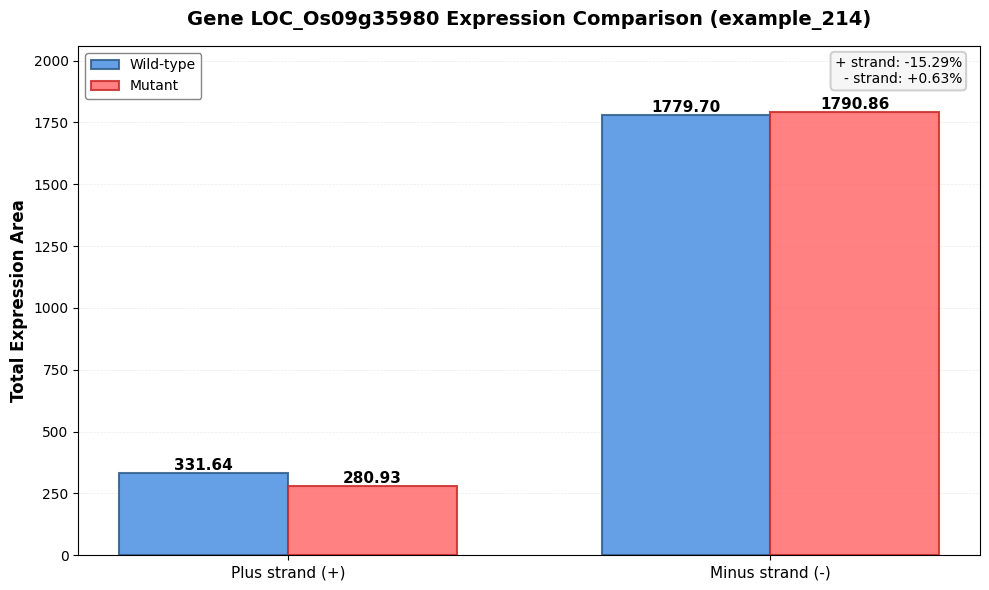

✅ Bar chart saved to: ./mutant_output_260525/example_214_expression.png


<Figure size 640x480 with 0 Axes>

In [18]:
if args.save_plots:
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(2)
    width = 0.35
    bars1 = ax.bar(x - width/2, [expression_ref_plus, expression_ref_minus], width, label='Wild-type',
                    color='#4A90E2', alpha=0.85, edgecolor='#2E5C8A', linewidth=1.5)
    bars2 = ax.bar(x + width/2, [expression_mut_plus, expression_mut_minus], width, label='Mutant',
                    color='#FF6B6B', alpha=0.85, edgecolor='#C92A2A', linewidth=1.5)
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel('Total Expression Area', fontsize=12, fontweight='bold')
    ax.set_title(f'Gene {gene_ID} Expression Comparison ({example_name})',
                    fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(['Plus strand (+)', 'Minus strand (-)'], fontsize=11)
    ax.set_ylim(0, max(expression_ref_plus, expression_ref_minus, expression_mut_plus, expression_mut_minus) * 1.15)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.95, edgecolor='gray')
    ax.grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    stats_text = f'+ strand: {plus_change:+.2f}%\n- strand: {minus_change:+.2f}%'
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.9, edgecolor='#CCCCCC', linewidth=1.5))
    plt.tight_layout()
    plot_path = os.path.join(args.output_dir, f"{example_name}_expression.png")
    plt.show()
    plt.savefig(plot_path, dpi=150)
    plt.close(fig)
    print(f"✅ Bar chart saved to: {plot_path}")

In [19]:
print(len(mut_plus), len(ref_plus), length_diff)

32767 32768 0


In [20]:
window_start=20716773
window_end=20749540


--- Generating track comparison plot ---


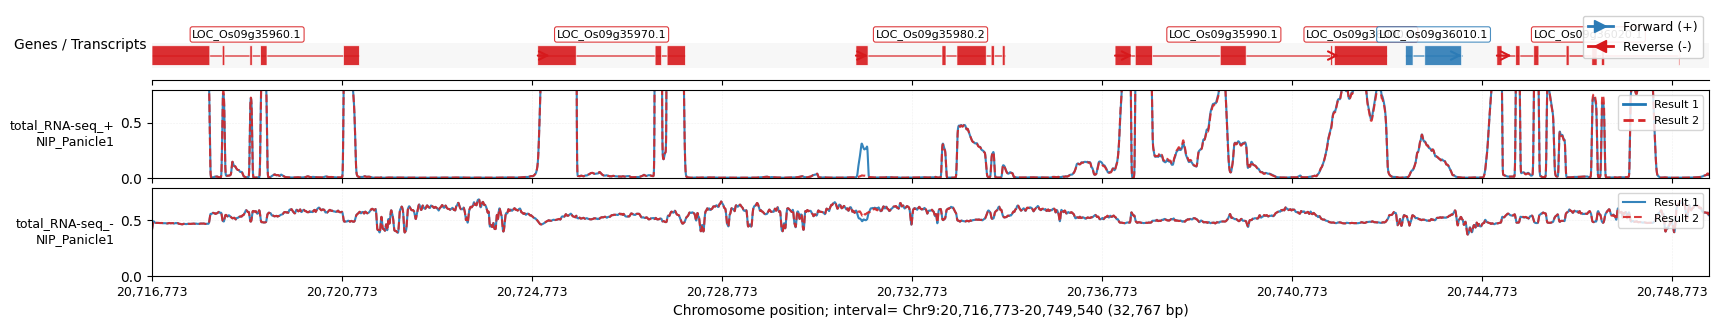

✅ Track comparison plot saved to: ./mutant_output_260525/example_214_tracks.png


In [21]:
# track_window_pad
if args.plot_tracks and viewer is not None:
    print("\n--- Generating track comparison plot ---")
    try:
        # 计算基因区域最大值（仍使用原始基因区间，与显示窗口无关）
        gene_relative_start = gene_start - window_start - 1
        gene_relative_end = gene_end - window_start
        ref_plus = ref_predict['values']['total_RNA-seq_+']['NIP_Panicle1'].float().cpu().numpy().flatten()
        ref_minus = ref_predict['values']['total_RNA-seq_-']['NIP_Panicle1'].float().cpu().numpy().flatten()
        mut_plus = mut_predict['values']['total_RNA-seq_+']['NIP_Panicle1'].float().cpu().numpy().flatten()
        mut_minus = mut_predict['values']['total_RNA-seq_-']['NIP_Panicle1'].float().cpu().numpy().flatten()

        gene_region_ref = slice(gene_relative_start, gene_relative_end)
        gene_region_mut = slice(gene_relative_start, gene_relative_end + length_diff)

        max_ref_plus = ref_plus[gene_region_ref].max() if len(ref_plus[gene_region_ref]) > 0 else 0
        max_ref_minus = ref_minus[gene_region_ref].max() if len(ref_minus[gene_region_ref]) > 0 else 0
        max_mut_plus = mut_plus[gene_region_mut].max() if len(mut_plus[gene_region_mut]) > 0 else 0
        max_mut_minus = mut_minus[gene_region_mut].max() if len(mut_minus[gene_region_mut]) > 0 else 0
        y_max = max(max_ref_plus, max_ref_minus, max_mut_plus, max_mut_minus) * 1.05

        # # 确定显示窗口
        # if args.track_window_pad is not None:
        #     display_start = max(0, gene_start - args.track_window_pad)
        #     display_end = gene_end + args.track_window_pad
        # else:
        #     display_start = window_start
        #     display_end = window_end

        display_start = window_start
        display_end = window_end

        fig, axes = viewer.plot3(
            ref_predict, mut_predict,
            smoothing_sigma=args.smoothing_sigma,
            window_start=display_start,
            window_end=display_end,
            exclude_legend_labels=["NIP_Panicle1"]
        )

        # 设置 y 轴范围
        if len(axes) >= 3:
            axes[1].set_ylim(0, y_max)
            axes[2].set_ylim(0, y_max)
        else:
            for ax in axes[1:]:
                if ax.get_ylabel() and ('RNA-seq' in ax.get_ylabel()):
                    ax.set_ylim(0, y_max)

        track_plot_path = os.path.join(args.output_dir, f"{example_name}_tracks.png")
        plt.show()
        fig.savefig(track_plot_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"✅ Track comparison plot saved to: {track_plot_path}")
    except Exception as e:
        print(f"⚠️ Failed to generate track plot: {e}")

In [23]:
ref_predict_modified = {
    'sequence': ref_predict['sequence'],
    'position': ref_predict['position'],
    'values': {
        'total_RNA-seq': ref_predict['values']['total_RNA-seq_+']
    }
}

mut_predict_modified = {
    'sequence': mut_predict['sequence'],
    'position': mut_predict['position'],
    'values': {
        'total_RNA-seq': mut_predict['values']['total_RNA-seq_+']
    }
}

In [25]:
!awk '$3=="exon" && /LOC_Os09g35980\.2/' /mnt/rice/default/Workspace/Rice-Genome/application/RNAseq/mutant_predict/mutant_output_260525/modified_osa1_r7.all_models.gff3 | awk '{print $4, $5}'

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


20734669 20734728
20734435 20734501
20733715 20734331
20731589 20731844
20733400 20733484


In [26]:
exon_list = [[20734669,20734728],
[20734435,20734501],
[20733715,20734331],
[20731589,20731844],
[20733400,20733484]]


--- Generating track comparison plot ---


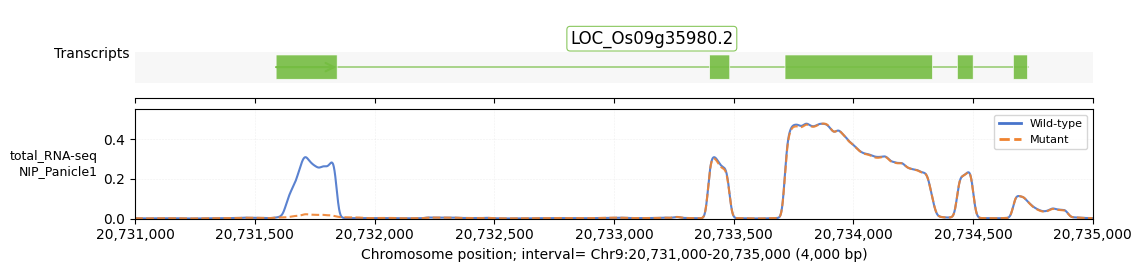

✅ Track comparison plot saved to: ./mutant_output_260525/example_214_tracks.pdf


In [27]:
# 导入自定义模块（需确保 src 目录在 Python 路径中）
from src.dataset import MultiTrackDataset, load_fasta_sequence
from src.viewer import DatasetViewer, ResultsViewer
from src.model import GenOmics, load_finetuned_model

# track_window_pad
if args.plot_tracks and viewer is not None:
    print("\n--- Generating track comparison plot ---")
    try:
        # 计算基因区域最大值（仍使用原始基因区间，与显示窗口无关）
        gene_relative_start = gene_start - window_start - 1
        gene_relative_end = gene_end - window_start
        ref_plus = ref_predict['values']['total_RNA-seq_+']['NIP_Panicle1'].float().cpu().numpy().flatten()
        mut_plus = mut_predict['values']['total_RNA-seq_+']['NIP_Panicle1'].float().cpu().numpy().flatten()

        gene_region_ref = slice(gene_relative_start, gene_relative_end)
        gene_region_mut = slice(gene_relative_start, gene_relative_end + length_diff)

        max_ref_plus = ref_plus[gene_region_ref].max() if len(ref_plus[gene_region_ref]) > 0 else 0
        max_mut_plus = mut_plus[gene_region_mut].max() if len(mut_plus[gene_region_mut]) > 0 else 0
        y_max = max(max_ref_plus, max_mut_plus) * 1.05

        # # 确定显示窗口
        # if args.track_window_pad is not None:
        #     display_start = max(0, gene_start - args.track_window_pad)
        #     display_end = gene_end + args.track_window_pad
        # else:
        #     display_start = window_start
        #     display_end = window_end

        # display_start = 20728773
        # display_end = 20736773
        # 20731589 - 20734728
        display_start = 20731000
        display_end = 20735000

        fig, axes = viewer.plot4(
            ref_predict_modified, mut_predict_modified,
            smoothing_sigma=args.smoothing_sigma,
            gene_color_minus="#75bd42",
            figsize=(12, 3),
            label_fontsize=12,
            window_start=display_start,
            window_end=display_end,
            exclude_legend_labels=["NIP_Panicle1"]
        )
        # # 设置 y 轴范围
        # if len(axes) >= 3:
        #     axes[1].set_ylim(0, y_max)
        #     axes[2].set_ylim(0, y_max)
        # else:
        #     for ax in axes[1:]:
        #         if ax.get_ylabel() and ('RNA-seq' in ax.get_ylabel()):
        #             ax.set_ylim(0, y_max)

        track_plot_path = os.path.join(args.output_dir, f"{example_name}_tracks.pdf")
        plt.show()
        fig.savefig(track_plot_path, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"✅ Track comparison plot saved to: {track_plot_path}")
    except Exception as e:
        print(f"⚠️ Failed to generate track plot: {e}")

process: 1
process: 1
process: 2
process: 3
process: 4
process: 5


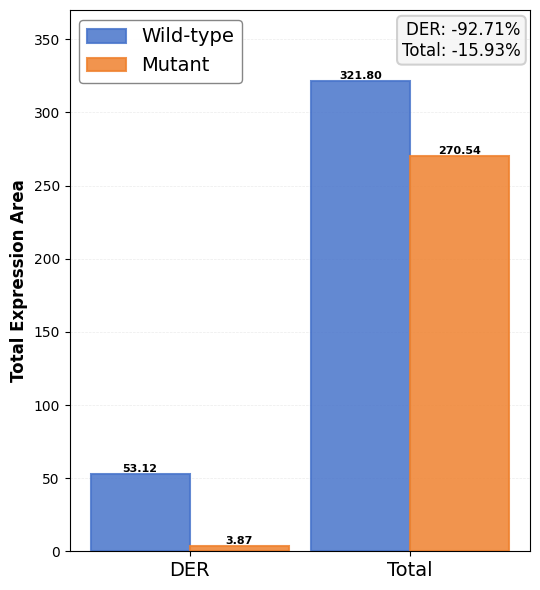

✅ Bar chart saved to: ./mutant_output_260525/example_214_expression.png


<Figure size 640x480 with 0 Axes>

In [28]:
expression_ref_plus=0
expression_mut_plus=0
n=1
for i in exon_list[3:4]:
    print(f"process: {n}")
    gene_start = i[0]
    gene_end = i[1]
    gene_relative_start = gene_start - window_start - 1
    gene_relative_end = gene_end - window_start
    expression_ref_plus0 = ref_plus[gene_relative_start:gene_relative_end].sum()
    expression_mut_plus0 = mut_plus[gene_relative_start:gene_relative_end + length_diff].sum()
    expression_ref_plus+=expression_ref_plus0
    expression_mut_plus+=expression_mut_plus0
    n +=1

plus_change = ((expression_mut_plus - expression_ref_plus) / expression_ref_plus) * 100 if expression_ref_plus != 0 else 0

expression_ref_minus=0
expression_mut_minus=0
n=1
for i in exon_list:
    print(f"process: {n}")
    gene_start = i[0]
    gene_end = i[1]
    gene_relative_start = gene_start - window_start - 1
    gene_relative_end = gene_end - window_start
    expression_ref_minus0 = ref_plus[gene_relative_start:gene_relative_end].sum()
    expression_mut_minus0 = mut_plus[gene_relative_start:gene_relative_end + length_diff].sum()
    expression_ref_minus+=expression_ref_minus0
    expression_mut_minus+=expression_mut_minus0
    n +=1

minus_change = ((expression_mut_minus - expression_ref_minus) / expression_ref_minus) * 100 if expression_ref_minus != 0 else 0

if args.save_plots:
    fig, ax = plt.subplots(figsize=(5.5, 6))
    x = np.arange(2)
    width = 0.45
    bars1 = ax.bar(x - width/2, [expression_ref_plus, expression_ref_minus], width, label='Wild-type',
                    color='#4874CB', alpha=0.85, edgecolor='#4874CB', linewidth=1.5)
    bars2 = ax.bar(x + width/2, [expression_mut_plus, expression_mut_minus], width, label='Mutant',
                    color='#ef822f', alpha=0.85, edgecolor='#ef822f', linewidth=1.5)
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_ylabel('Total Expression Area', fontsize=12, fontweight='bold')
    # ax.set_title(f'Gene {gene_ID} Expression Comparison',
    #                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(['DER', 'Total'], fontsize=14)
    ax.set_ylim(0, max(expression_ref_plus, expression_ref_minus, expression_mut_plus, expression_mut_minus) * 1.15)
    ax.legend(loc='upper left', fontsize=14, framealpha=0.95, edgecolor='gray')
    ax.grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)
    stats_text = f'DER: {plus_change:+.2f}%\nTotal: {minus_change:+.2f}%'
    ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
            fontsize=12, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.9, edgecolor='#CCCCCC', linewidth=1.5))
    plt.tight_layout()
    plot_path = os.path.join(args.output_dir, f"{example_name}_expression.png")
    plt.show()
    plt.savefig(plot_path, dpi=150)
    plt.close(fig)
    print(f"✅ Bar chart saved to: {plot_path}")
